# ResNet-18 Training on FERPlus

This notebook trains **ResNet-18** (ImageNet pretrained, transfer learning)
for facial emotion recognition using the FERPlus dataset. It is designed to run
with a Google Colab GPU kernel via the VS Code Colab integration.

**Workflow:**
1. **Phase 1 -- Base run:** Freeze the backbone entirely, train only the
   classifier head, and evaluate.
2. **Phase 2 -- Optimized run:** Unfreeze the last 2 residual layers and use
   a 2-layer classifier head (matching `models/resnet.py`), with
   differential learning rates and a LR scheduler.

Phase 2 is included because frozen-backbone baselines typically show
underfitting on FERPlus: the pretrained ImageNet features need adaptation
for grayscale facial expression data. The project's own architecture
(`models/resnet.py`) uses partial backbone unfreezing by default.

**Important:** Make sure you select a GPU runtime
(Runtime > Change runtime type > T4 GPU).

## 0. Google Drive Mount (Optional)

Mount Google Drive so that output artifacts (checkpoints, plots, metrics)
can be copied to a Drive folder for easy download after Colab disconnects.
Skip this cell if you do not need Drive access.

In [1]:
# Set SAVE_TO_DRIVE = True to copy outputs to Google Drive
SAVE_TO_DRIVE = True
DRIVE_OUTPUT_DIR = (
    "/content/drive/MyDrive/"
    "emotion_project/results/resnet18"
)

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    import os
    os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
    print(f"Drive output dir: {DRIVE_OUTPUT_DIR}")
else:
    print("Google Drive mount skipped.")

Mounted at /content/drive
Drive output dir: /content/drive/MyDrive/emotion_project/results/resnet18


## 1. Environment Setup

In [2]:
# GPU availability check
!nvidia-smi

import torch
print(f"\nPyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("[WARNING] No GPU detected. Select a GPU runtime.")

Sun Mar 15 15:15:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Clone the repository from GitHub
import os

REPO_URL = (
    "https://github.com/aysenurhepguven0/"
    "adaptive-emotion-aware-virtual-interaction-system.git"
)
REPO_DIR = (
    "/content/"
    "adaptive-emotion-aware-virtual-interaction-system"
)

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    print(f"Repository already exists at {REPO_DIR}")

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

Cloning into '/content/adaptive-emotion-aware-virtual-interaction-system'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 47 (delta 12), reused 40 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (47/47), 426.73 KiB | 4.27 MiB/s, done.
Resolving deltas: 100% (12/12), done.
Working directory: /content/adaptive-emotion-aware-virtual-interaction-system


In [4]:
# Install project dependencies
%pip install -q -r requirements.txt
%pip install -q kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.5 MB/s eta 0:00:00


## 2. Configuration and Imports

In [5]:
import sys
import json
import time
import shutil
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

# Ensure project root is on the import path
PROJECT_ROOT = Path(REPO_DIR).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print("Imports complete.")

Project root: /content/adaptive-emotion-aware-virtual-interaction-system
Imports complete.


In [6]:
# --- Paths ---
DATASET_PATH = PROJECT_ROOT / "data" / "ferplus"
OUTPUT_DIR = PROJECT_ROOT / "results" / "resnet18"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Device ---
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Speed up convolutions for fixed input size
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

# --- Class filter ---
# FERPlus has 8 classes but Contempt, Disgust, and Fear have
# too few test samples and hurt macro-weighted F1. Use 5 classes.
TARGET_CLASSES = ["angry", "happy", "neutral", "sad", "suprise"]

# --- Hyperparameters (shared / Phase 2) ---
NUM_EPOCHS = 30 if torch.cuda.is_available() else 10
BATCH_SIZE = 128 if torch.cuda.is_available() else 32
INPUT_SIZE = 224  # ResNet-18 standard input resolution
EARLY_STOPPING_PATIENCE = 10

# --- Phase 1 hyperparameters (frozen backbone) ---
PHASE1_LR = 1e-3
PHASE1_WEIGHT_DECAY = 1e-4
PHASE1_DROPOUT = 0.4
PHASE1_EPOCHS = 10
PHASE1_PATIENCE = 5

# --- Phase 2 hyperparameters (partial fine-tuning) ---
PHASE2_BACKBONE_LR = 1e-5
PHASE2_CLASSIFIER_LR = 1e-4
PHASE2_WEIGHT_DECAY = 1e-4
PHASE2_UNFREEZE_LAST_N = 2

print(f"Device:     {DEVICE}")
print(f"P1 epochs:  {PHASE1_EPOCHS} (patience {PHASE1_PATIENCE})")
print(f"P2 epochs:  {NUM_EPOCHS} (patience {EARLY_STOPPING_PATIENCE})")
print(f"Batch size: {BATCH_SIZE}")
print(f"Input size: {INPUT_SIZE}x{INPUT_SIZE}")
print(f"Classes:    {TARGET_CLASSES}")
print(f"Dataset:    {DATASET_PATH}")
print(f"Output dir: {OUTPUT_DIR}")

Device:     cuda
P1 epochs:  10 (patience 5)
P2 epochs:  30 (patience 10)
Batch size: 128
Input size: 224x224
Classes:    ['angry', 'happy', 'neutral', 'sad', 'suprise']
Dataset:    /content/adaptive-emotion-aware-virtual-interaction-system/data/ferplus
Output dir: /content/adaptive-emotion-aware-virtual-interaction-system/results/resnet18


## 3. Dataset Preparation

In [7]:
# Download FERPlus from Kaggle if not already present
import kagglehub

splits_exist = (
    (DATASET_PATH / "train").exists()
    and (DATASET_PATH / "test").exists()
)

if not splits_exist:
    print("Downloading FERPlus dataset from Kaggle...")
    ferplus_download = kagglehub.dataset_download(
        "arnabkumarroy02/ferplus"
    )
    DATASET_PATH.mkdir(parents=True, exist_ok=True)
    !cp -r {ferplus_download}/* {DATASET_PATH}/
    print(f"Dataset saved to: {DATASET_PATH}")
else:
    print(f"Dataset already exists at: {DATASET_PATH}")

100%|██████████| 487M/487M [00:12<00:00, 40.0MB/s] 

Extracting files...


Dataset saved to: /content/adaptive-emotion-aware-virtual-interaction-system/data/ferplus


In [8]:
# Verify dataset structure
print("FERPlus dataset structure:")
for split in ["train", "validation", "test"]:
    split_path = DATASET_PATH / split
    if split_path.exists():
        classes = sorted(
            d.name for d in split_path.iterdir()
            if d.is_dir()
        )
        total = sum(
            len(list((split_path / c).iterdir()))
            for c in classes
        )
        print(
            f"  {split:12s}: {total:>6,} images, "
            f"{len(classes)} classes"
        )
    else:
        print(f"  {split:12s}: NOT FOUND")

FERPlus dataset structure:
  train       : 66,379 images, 8 classes
  validation  :  8,341 images, 8 classes
  test        :  3,573 images, 8 classes


In [9]:
# Build transforms and create DataLoaders
# FERPlus images are 48x48 grayscale; resize to 224x224 and
# convert to 3-channel for ResNet-18.
train_transforms = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.1, contrast=0.1, saturation=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transforms = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


def filter_classes(dataset, target_classes):
    """Keep only samples belonging to target_classes
    and remap labels to 0..len(target_classes)-1."""
    keep_indices = {
        dataset.class_to_idx[c] for c in target_classes
        if c in dataset.class_to_idx
    }
    idx_map = {
        old: new
        for new, old in enumerate(sorted(keep_indices))
    }
    dataset.samples = [
        (path, idx_map[label])
        for path, label in dataset.samples
        if label in idx_map
    ]
    dataset.targets = [s[1] for s in dataset.samples]
    dataset.classes = [
        c for c in dataset.classes
        if dataset.class_to_idx.get(c) in keep_indices
    ]
    dataset.class_to_idx = {
        c: i for i, c in enumerate(dataset.classes)
    }
    return dataset


train_dataset = datasets.ImageFolder(
    DATASET_PATH / "train", transform=train_transforms
)
val_dataset = datasets.ImageFolder(
    DATASET_PATH / "validation", transform=eval_transforms
)
test_dataset = datasets.ImageFolder(
    DATASET_PATH / "test", transform=eval_transforms
)

# Filter to 5 target classes
filter_classes(train_dataset, TARGET_CLASSES)
filter_classes(val_dataset, TARGET_CLASSES)
filter_classes(test_dataset, TARGET_CLASSES)

CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

_loader_kwargs = dict(
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, **_loader_kwargs,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, **_loader_kwargs,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, **_loader_kwargs,
)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(
    f"Train: {len(train_dataset):,} | "
    f"Val: {len(val_dataset):,} | "
    f"Test: {len(test_dataset):,}"
)

Classes (5): ['angry', 'happy', 'neutral', 'sad', 'suprise']
Train: 42,379 | Val: 5,341 | Test: 3,424


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 4. Helper Functions

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    """Train for one epoch. Returns (loss, accuracy)."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    use_amp = scaler is not None and device.type == "cuda"
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)
        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        running_loss += loss.item() * labels.size(0)
        correct += (
            (outputs.argmax(dim=1) == labels).sum().item()
        )
        total += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate on a data loader. Returns (loss, accuracy)."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    use_amp = device.type == "cuda"
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(device_type="cuda", enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
            correct += (
                (outputs.argmax(dim=1) == labels)
                .sum().item()
            )
            total += labels.size(0)
    return running_loss / total, correct / total


def run_training_loop(
    model, train_loader, val_loader, criterion,
    optimizer, num_epochs, patience, checkpoint_path,
    device, scheduler=None, scaler=None,
):
    """Full training loop with early stopping.

    Returns:
        history (dict): train/val loss and accuracy per epoch.
        best_val_acc (float): Best validation accuracy achieved.
    """
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": [],
    }
    best_val_acc = 0.0
    patience_counter = 0

    for epoch in range(1, num_epochs + 1):
        start = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer,
            device, scaler=scaler,
        )
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )
        elapsed = time.time() - start

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if scheduler is not None:
            scheduler.step(val_loss)

        marker = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(
                model.state_dict(), checkpoint_path
            )
            patience_counter = 0
            marker = " [BEST]"
        else:
            patience_counter += 1

        print(
            f"Epoch {epoch:>2}/{num_epochs} "
            f"({elapsed:.0f}s) | "
            f"Train {train_loss:.4f} / {train_acc:.2%} | "
            f"Val {val_loss:.4f} / {val_acc:.2%}{marker}"
        )

        if patience_counter >= patience:
            print(
                f"Early stopping at epoch {epoch} "
                f"(no improvement for {patience} epochs)"
            )
            break

    return history, best_val_acc


def predict_test_set(model, loader, device):
    """Run inference on the test set.

    Returns:
        y_true (list): Ground truth labels.
        y_pred (list): Predicted labels.
    """
    model.eval()
    y_true, y_pred = [], []
    use_amp = device.type == "cuda"
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(device_type="cuda", enabled=use_amp):
                outputs = model(images)
            preds = outputs.argmax(dim=1)
            y_true.extend(labels.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())
    return y_true, y_pred


def plot_training_history(history, title, save_path):
    """Plot loss and accuracy curves and save to disk."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs_range = range(
        1, len(history["train_loss"]) + 1
    )

    axes[0].plot(
        epochs_range, history["train_loss"], label="Train"
    )
    axes[0].plot(
        epochs_range, history["val_loss"],
        label="Validation",
    )
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(
        epochs_range, history["train_acc"], label="Train"
    )
    axes[1].plot(
        epochs_range, history["val_acc"],
        label="Validation",
    )
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")


def plot_confusion_matrices(
    y_true, y_pred, class_names, title_prefix, save_dir
):
    """Plot and save normalized and count confusion matrices."""
    cm = confusion_matrix(
        y_true, y_pred, normalize="true"
    )
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=class_names
    )
    disp.plot(
        ax=ax, cmap="Blues",
        values_format=".2f", colorbar=True,
    )
    ax.set_title(f"{title_prefix} Confusion Matrix")
    fig.tight_layout()
    norm_path = save_dir / "confusion_matrix.png"
    fig.savefig(norm_path, dpi=150)
    plt.show()

    cm_counts = confusion_matrix(y_true, y_pred)
    fig2, ax2 = plt.subplots(figsize=(8, 6))
    disp2 = ConfusionMatrixDisplay(
        confusion_matrix=cm_counts,
        display_labels=class_names,
    )
    disp2.plot(
        ax=ax2, cmap="Blues",
        values_format="d", colorbar=True,
    )
    ax2.set_title(
        f"{title_prefix} Confusion Matrix - Counts"
    )
    fig2.tight_layout()
    counts_path = save_dir / "confusion_matrix_counts.png"
    fig2.savefig(counts_path, dpi=150)
    plt.show()

    print(f"Saved: {norm_path}")
    print(f"Saved: {counts_path}")


def save_outputs(
    history, y_true, y_pred, class_names,
    model_name, best_val_acc, extra_info, save_dir,
):
    """Save training history and evaluation summary as JSON."""
    history_path = save_dir / "training_history.json"
    with open(history_path, "w") as f:
        json.dump(history, f, indent=2)

    test_acc = sum(
        t == p for t, p in zip(y_true, y_pred)
    ) / len(y_true)
    report_dict = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True,
    )
    eval_summary = {
        "model": model_name,
        "dataset": "ferplus",
        "num_classes": len(class_names),
        "class_names": list(class_names),
        "input_size": INPUT_SIZE,
        "epochs_trained": len(history["train_loss"]),
        "best_val_accuracy": best_val_acc,
        "test_accuracy": test_acc,
        "classification_report": report_dict,
    }
    eval_summary.update(extra_info)
    eval_path = save_dir / "evaluation_summary.json"
    with open(eval_path, "w") as f:
        json.dump(eval_summary, f, indent=2)

    print(f"All outputs saved to: {save_dir}")
    print("-" * 50)
    for p in sorted(save_dir.iterdir()):
        size_kb = p.stat().st_size / 1024
        print(f"  {p.name:40s} {size_kb:>8.1f} KB")

    return test_acc


def copy_to_drive(src_dir, drive_dir):
    """Copy all files from src_dir to drive_dir."""
    if not SAVE_TO_DRIVE:
        print("Drive save skipped (SAVE_TO_DRIVE=False).")
        return
    drive_path = Path(drive_dir)
    drive_path.mkdir(parents=True, exist_ok=True)
    for f in sorted(Path(src_dir).iterdir()):
        if f.is_file():
            shutil.copy2(f, drive_path / f.name)
        elif f.is_dir():
            sub_dest = drive_path / f.name
            sub_dest.mkdir(parents=True, exist_ok=True)
            for sf in sorted(f.iterdir()):
                if sf.is_file():
                    shutil.copy2(sf, sub_dest / sf.name)
    print(f"Copied outputs to Drive: {drive_path}")

---

## Phase 1 -- Base Run (Frozen Backbone)

Train only the classifier head with the entire backbone frozen.
This serves as the baseline to determine whether optimization
is needed.

### 5a. Model Initialization (Phase 1)

In [11]:
# Load ResNet-18 with ImageNet pretrained weights.
# Freeze the entire backbone; train only a single linear head.
model_p1 = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

# Freeze backbone
for param in model_p1.parameters():
    param.requires_grad = False

# Simple classifier: Dropout -> Linear
in_features = model_p1.fc.in_features  # 512
model_p1.fc = nn.Sequential(
    nn.Dropout(p=PHASE1_DROPOUT, inplace=True),
    nn.Linear(in_features, NUM_CLASSES),
)

model_p1 = model_p1.to(DEVICE)

total_params = sum(p.numel() for p in model_p1.parameters())
trainable_params = sum(
    p.numel() for p in model_p1.parameters()
    if p.requires_grad
)

print("Phase 1: ResNet-18 (frozen backbone)")
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(
    f"  Frozen parameters:    "
    f"{total_params - trainable_params:,}"
)
print(f"  Number of classes:    {NUM_CLASSES}")
print(f"  Input size:           {INPUT_SIZE}x{INPUT_SIZE}x3")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 214MB/s]


Phase 1: ResNet-18 (frozen backbone)
  Total parameters:     11,179,077
  Trainable parameters: 2,565
  Frozen parameters:    11,176,512
  Number of classes:    5
  Input size:           224x224x3


### 5b. Training (Phase 1)

In [12]:
# Output directory for Phase 1
P1_DIR = OUTPUT_DIR / "phase1_frozen"
P1_DIR.mkdir(parents=True, exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer_p1 = torch.optim.Adam(
    model_p1.parameters(),
    lr=PHASE1_LR,
    weight_decay=PHASE1_WEIGHT_DECAY,
)

# Mixed-precision scaler; None on CPU (no-op fallback)
scaler_p1 = (
    torch.amp.GradScaler("cuda")
    if torch.cuda.is_available() else None
)

print("Phase 1: Training ResNet-18 (frozen backbone)")
print(
    f"  Device: {DEVICE} | Batch: {BATCH_SIZE} | "
    f"LR: {PHASE1_LR} | AMP: {scaler_p1 is not None}"
)
print("=" * 70)

history_p1, best_val_acc_p1 = run_training_loop(
    model=model_p1,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_p1,
    num_epochs=PHASE1_EPOCHS,
    patience=PHASE1_PATIENCE,
    checkpoint_path=P1_DIR / "best_model.pth",
    device=DEVICE,
    scaler=scaler_p1,
)

print("=" * 70)
print(f"Phase 1 best val accuracy: {best_val_acc_p1:.2%}")

Phase 1: Training ResNet-18 (frozen backbone)
  Device: cuda | Batch: 128 | LR: 0.001 | AMP: True


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch  1/10 (210s) | Train 1.3916 / 41.16% | Val 1.2294 / 51.21% [BEST]
Epoch  2/10 (205s) | Train 1.2828 / 47.30% | Val 1.2139 / 52.29% [BEST]
Epoch  3/10 (208s) | Train 1.2742 / 47.67% | Val 1.1906 / 52.80% [BEST]
Epoch  4/10 (205s) | Train 1.2725 / 47.96% | Val 1.1787 / 53.38% [BEST]
Epoch  5/10 (209s) | Train 1.2758 / 47.34% | Val 1.1949 / 52.24%
Epoch  6/10 (208s) | Train 1.2779 / 47.25% | Val 1.1778 / 52.97%
Epoch  7/10 (209s) | Train 1.2764 / 47.23% | Val 1.1904 / 52.63%
Epoch  8/10 (206s) | Train 1.2762 / 47.90% | Val 1.1859 / 52.67%
Epoch  9/10 (206s) | Train 1.2758 / 47.71% | Val 1.1907 / 53.44% [BEST]
Epoch 10/10 (207s) | Train 1.2762 / 47.20% | Val 1.2080 / 50.81%
Phase 1 best val accuracy: 53.44%


### 5c. Evaluation (Phase 1)

In [13]:
# Load best Phase 1 checkpoint and evaluate
model_p1.load_state_dict(
    torch.load(
        P1_DIR / "best_model.pth", map_location=DEVICE
    )
)

y_true_p1, y_pred_p1 = predict_test_set(
    model_p1, test_loader, DEVICE
)
test_acc_p1 = sum(
    t == p for t, p in zip(y_true_p1, y_pred_p1)
) / len(y_true_p1)

print(f"Phase 1 Test Accuracy: {test_acc_p1:.2%}")
print()
print(classification_report(
    y_true_p1, y_pred_p1, target_names=CLASS_NAMES
))

Phase 1 Test Accuracy: 53.21%

              precision    recall  f1-score   support

       angry       0.42      0.11      0.17       322
       happy       0.48      0.70      0.57       929
     neutral       0.58      0.66      0.62      1274
         sad       0.36      0.15      0.22       449
     suprise       0.63      0.50      0.56       450

    accuracy                           0.53      3424
   macro avg       0.49      0.42      0.43      3424
weighted avg       0.52      0.53      0.50      3424



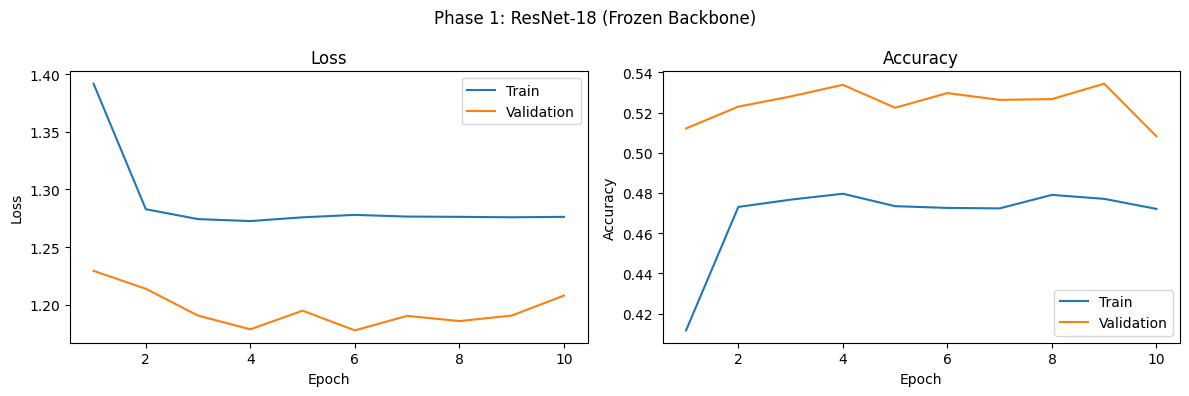

Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/resnet18/phase1_frozen/training_history.png


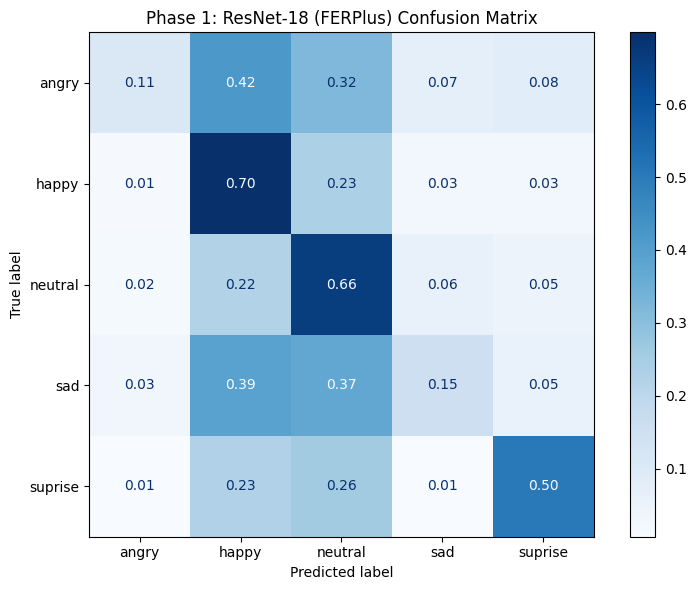

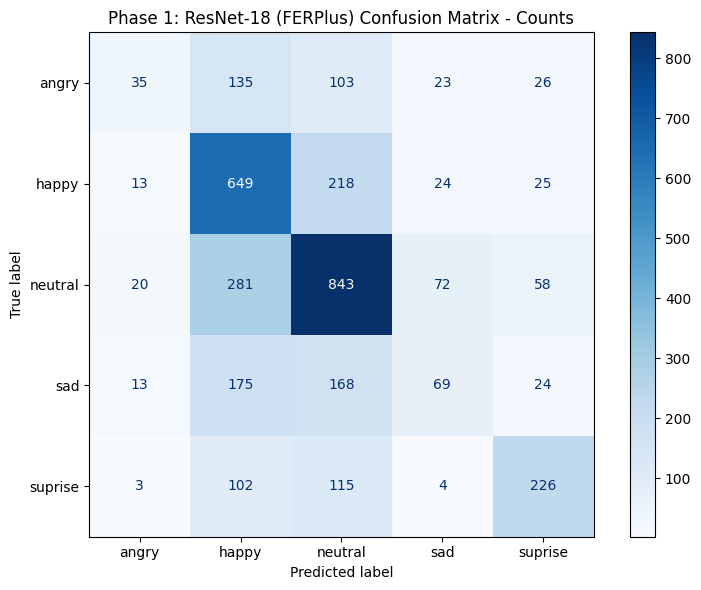

Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/resnet18/phase1_frozen/confusion_matrix.png
Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/resnet18/phase1_frozen/confusion_matrix_counts.png


In [14]:
# Phase 1 training curves
plot_training_history(
    history_p1,
    "Phase 1: ResNet-18 (Frozen Backbone)",
    P1_DIR / "training_history.png",
)

# Phase 1 confusion matrices
plot_confusion_matrices(
    y_true_p1, y_pred_p1, CLASS_NAMES,
    "Phase 1: ResNet-18 (FERPlus)", P1_DIR,
)

In [15]:
# Save Phase 1 outputs
save_outputs(
    history=history_p1,
    y_true=y_true_p1,
    y_pred=y_pred_p1,
    class_names=CLASS_NAMES,
    model_name="resnet18_phase1_frozen",
    best_val_acc=best_val_acc_p1,
    extra_info={
        "phase": "phase1_frozen_backbone",
        "dropout": PHASE1_DROPOUT,
        "learning_rate": PHASE1_LR,
        "trainable_params": sum(
            p.numel() for p in model_p1.parameters()
            if p.requires_grad
        ),
    },
    save_dir=P1_DIR,
)

All outputs saved to: /content/adaptive-emotion-aware-virtual-interaction-system/results/resnet18/phase1_frozen
--------------------------------------------------
  best_model.pth                            43746.1 KB
  confusion_matrix.png                         69.1 KB
  confusion_matrix_counts.png                  68.5 KB
  evaluation_summary.json                       1.6 KB
  training_history.json                         1.0 KB
  training_history.png                         75.3 KB


0.532126168224299

### 5d. Phase 1 Analysis

Check whether the Phase 1 results justify running Phase 2.
Criteria for triggering optimization:
- Test accuracy below 60% (poor for a 5-class problem)
- Training accuracy close to or below validation accuracy
  (indicates underfitting, not overfitting)
- Macro F1 below 0.55

In [16]:
# Decision logic for Phase 2
report_dict_p1 = classification_report(
    y_true_p1, y_pred_p1,
    target_names=CLASS_NAMES,
    output_dict=True,
)
macro_f1_p1 = report_dict_p1["macro avg"]["f1-score"]
final_train_acc = history_p1["train_acc"][-1]

print("Phase 1 Results Summary:")
print(f"  Test accuracy:     {test_acc_p1:.2%}")
print(f"  Macro F1:          {macro_f1_p1:.4f}")
print(f"  Final train acc:   {final_train_acc:.2%}")
print(f"  Best val acc:      {best_val_acc_p1:.2%}")
print()

is_underfitting = final_train_acc <= best_val_acc_p1 + 0.02
is_low_accuracy = test_acc_p1 < 0.60
is_low_f1 = macro_f1_p1 < 0.55

run_phase2 = is_underfitting or is_low_accuracy or is_low_f1

if run_phase2:
    reasons = []
    if is_underfitting:
        reasons.append(
            f"underfitting (train {final_train_acc:.2%} "
            f"<= val {best_val_acc_p1:.2%})"
        )
    if is_low_accuracy:
        reasons.append(
            f"low test accuracy ({test_acc_p1:.2%} < 60%)"
        )
    if is_low_f1:
        reasons.append(
            f"low macro F1 ({macro_f1_p1:.4f} < 0.55)"
        )
    print("DECISION: Phase 2 optimization IS justified.")
    print(f"  Reasons: {'; '.join(reasons)}")
    print()
    print(
        "  Phase 2 will unfreeze the last 2 residual "
        "layers and use a 2-layer classifier head, "
        "matching the architecture in models/resnet.py."
    )
else:
    print(
        "DECISION: Phase 1 results are acceptable. "
        "Phase 2 optimization is NOT needed."
    )
    print(
        "  Skip the Phase 2 cells below and proceed "
        "directly to the final summary."
    )

Phase 1 Results Summary:
  Test accuracy:     53.21%
  Macro F1:          0.4275
  Final train acc:   47.20%
  Best val acc:      53.44%

DECISION: Phase 2 optimization IS justified.
  Reasons: underfitting (train 47.20% <= val 53.44%); low test accuracy (53.21% < 60%); low macro F1 (0.4275 < 0.55)

  Phase 2 will unfreeze the last 2 residual layers and use a 2-layer classifier head, matching the architecture in models/resnet.py.


---

## Phase 2 -- Optimized Run (Partial Fine-Tuning)

This phase uses the `ResNet18` architecture defined inline
(mirroring `models/resnet.py` exactly):
- Backbone with last 2 residual layers unfrozen for feature adaptation
- 2-layer classifier head (512 -> 256 -> NUM_CLASSES)
- Differential learning rate: lower for backbone, higher for classifier
- ReduceLROnPlateau scheduler to escape loss plateaus

### 6a. Model Initialization (Phase 2)

In [17]:
if not run_phase2:
    print("Phase 2 skipped (Phase 1 results acceptable).")
else:
    # Define ResNet18 inline to keep the notebook self-contained.
    # This mirrors models/resnet.py exactly so outputs are identical
    # to the project module.
    class ResNet18(nn.Module):
        """ResNet-18 for emotion recognition (transfer learning).

        Architecture matches models/resnet.py:
          - ImageNet pretrained backbone
          - Optional grayscale->RGB adapter (in_channels=1)
          - Custom 2-layer classifier: 512 -> Dropout -> 256
            -> ReLU -> Dropout -> num_classes
          - Backbone frozen except last unfreeze_last_n
            residual layers
        """

        def __init__(
            self, num_classes=5, in_channels=3,
            freeze_backbone=True, unfreeze_last_n=2,
        ):
            super().__init__()
            self.in_channels = in_channels

            if in_channels == 1:
                self.channel_adapter = nn.Sequential(
                    nn.Conv2d(1, 3, kernel_size=1, bias=False),
                    nn.BatchNorm2d(3),
                )
            else:
                self.channel_adapter = None

            weights = models.ResNet18_Weights.IMAGENET1K_V1
            self.backbone = models.resnet18(weights=weights)

            in_features = self.backbone.fc.in_features  # 512
            self.backbone.fc = nn.Sequential(
                nn.Dropout(p=0.4),
                nn.Linear(in_features, 256),
                nn.ReLU(),
                nn.Dropout(p=0.3),
                nn.Linear(256, num_classes),
            )

            if freeze_backbone:
                self._freeze_backbone(unfreeze_last_n)

        def _freeze_backbone(self, unfreeze_last_n=2):
            layers = [
                self.backbone.conv1, self.backbone.bn1,
                self.backbone.layer1, self.backbone.layer2,
                self.backbone.layer3, self.backbone.layer4,
            ]
            for layer in layers:
                for param in layer.parameters():
                    param.requires_grad = False

            residual_layers = [
                self.backbone.layer1, self.backbone.layer2,
                self.backbone.layer3, self.backbone.layer4,
            ]
            for i in range(
                max(0, len(residual_layers) - unfreeze_last_n),
                len(residual_layers),
            ):
                for param in residual_layers[i].parameters():
                    param.requires_grad = True

            for param in self.backbone.fc.parameters():
                param.requires_grad = True

        def forward(self, x):
            if self.channel_adapter is not None:
                x = self.channel_adapter(x)
            return self.backbone(x)

    model_p2 = ResNet18(
        num_classes=NUM_CLASSES,
        in_channels=3,
        freeze_backbone=True,
        unfreeze_last_n=PHASE2_UNFREEZE_LAST_N,
    )
    model_p2 = model_p2.to(DEVICE)

    total_params = sum(p.numel() for p in model_p2.parameters())
    trainable_params = sum(
        p.numel() for p in model_p2.parameters()
        if p.requires_grad
    )

    print("Phase 2: ResNet18 (matching models/resnet.py)")
    print(f"  Total parameters:     {total_params:,}")
    print(f"  Trainable parameters: {trainable_params:,}")
    print(f"  Frozen parameters:    {total_params - trainable_params:,}")
    print(f"  Unfrozen layers:      last {PHASE2_UNFREEZE_LAST_N}")
    print(f"  Classifier head:      512 -> 256 -> {NUM_CLASSES}")
    print(f"  Input size:           {INPUT_SIZE}x{INPUT_SIZE}x3")

Phase 2: ResNet18 (matching models/resnet.py)
  Total parameters:     11,309,125
  Trainable parameters: 10,626,053
  Frozen parameters:    683,072
  Unfrozen layers:      last 2
  Classifier head:      512 -> 256 -> 5
  Input size:           224x224x3


### 6b. Training (Phase 2)

In [18]:
if not run_phase2:
    print("Phase 2 skipped.")
else:
    P2_DIR = OUTPUT_DIR / "phase2_finetuned"
    P2_DIR.mkdir(parents=True, exist_ok=True)

    # Collect unfrozen backbone params (layer3 + layer4)
    backbone_params = [
        p for n, p in model_p2.backbone.named_parameters()
        if p.requires_grad and not n.startswith("fc.")
    ]
    classifier_params = list(
        model_p2.backbone.fc.parameters()
    )

    optimizer_p2 = torch.optim.Adam([
        {
            "params": backbone_params,
            "lr": PHASE2_BACKBONE_LR,
        },
        {
            "params": classifier_params,
            "lr": PHASE2_CLASSIFIER_LR,
        },
    ], weight_decay=PHASE2_WEIGHT_DECAY)

    scheduler_p2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_p2, mode="min", factor=0.5, patience=3,
    )

    scaler_p2 = (
        torch.amp.GradScaler("cuda")
        if torch.cuda.is_available() else None
    )

    print("Phase 2: Training ResNet-18 (fine-tuned)")
    print(
        f"  Backbone LR: {PHASE2_BACKBONE_LR} | "
        f"Classifier LR: {PHASE2_CLASSIFIER_LR} | "
        f"AMP: {scaler_p2 is not None}"
    )
    print("=" * 70)

    history_p2, best_val_acc_p2 = run_training_loop(
        model=model_p2,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer_p2,
        num_epochs=NUM_EPOCHS,
        patience=EARLY_STOPPING_PATIENCE,
        checkpoint_path=P2_DIR / "best_model.pth",
        device=DEVICE,
        scheduler=scheduler_p2,
        scaler=scaler_p2,
    )

    print("=" * 70)
    print(f"Phase 2 best val accuracy: {best_val_acc_p2:.2%}")

Phase 2: Training ResNet-18 (fine-tuned)
  Backbone LR: 1e-05 | Classifier LR: 0.0001 | AMP: True
Epoch  1/30 (221s) | Train 1.1788 / 51.47% | Val 0.8438 / 68.06% [BEST]
Epoch  2/30 (207s) | Train 0.7773 / 70.19% | Val 0.6757 / 74.80% [BEST]
Epoch  3/30 (210s) | Train 0.6433 / 75.37% | Val 0.6185 / 77.48% [BEST]
Epoch  4/30 (208s) | Train 0.5649 / 78.52% | Val 0.5620 / 79.16% [BEST]
Epoch  5/30 (207s) | Train 0.5169 / 80.47% | Val 0.5424 / 80.38% [BEST]
Epoch  6/30 (209s) | Train 0.4779 / 81.89% | Val 0.5174 / 81.30% [BEST]
Epoch  7/30 (208s) | Train 0.4438 / 83.23% | Val 0.5072 / 81.88% [BEST]
Epoch  8/30 (210s) | Train 0.4129 / 84.43% | Val 0.5008 / 81.99% [BEST]
Epoch  9/30 (209s) | Train 0.3899 / 85.36% | Val 0.4965 / 82.19% [BEST]
Epoch 10/30 (209s) | Train 0.3659 / 86.25% | Val 0.4924 / 82.74% [BEST]
Epoch 11/30 (208s) | Train 0.3489 / 86.74% | Val 0.5017 / 82.98% [BEST]
Epoch 12/30 (208s) | Train 0.3281 / 87.51% | Val 0.4831 / 83.67% [BEST]
Epoch 13/30 (209s) | Train 0.3135 / 88

### 6c. Evaluation (Phase 2)

In [19]:
if not run_phase2:
    print("Phase 2 skipped.")
else:
    model_p2.load_state_dict(
        torch.load(
            P2_DIR / "best_model.pth",
            map_location=DEVICE,
        )
    )

    y_true_p2, y_pred_p2 = predict_test_set(
        model_p2, test_loader, DEVICE
    )
    test_acc_p2 = sum(
        t == p for t, p in zip(y_true_p2, y_pred_p2)
    ) / len(y_true_p2)

    print(f"Phase 2 Test Accuracy: {test_acc_p2:.2%}")
    print()
    print(classification_report(
        y_true_p2, y_pred_p2, target_names=CLASS_NAMES
    ))

Phase 2 Test Accuracy: 82.59%

              precision    recall  f1-score   support

       angry       0.76      0.77      0.77       322
       happy       0.91      0.91      0.91       929
     neutral       0.81      0.86      0.83      1274
         sad       0.68      0.56      0.62       449
     suprise       0.87      0.85      0.86       450

    accuracy                           0.83      3424
   macro avg       0.81      0.79      0.80      3424
weighted avg       0.82      0.83      0.82      3424



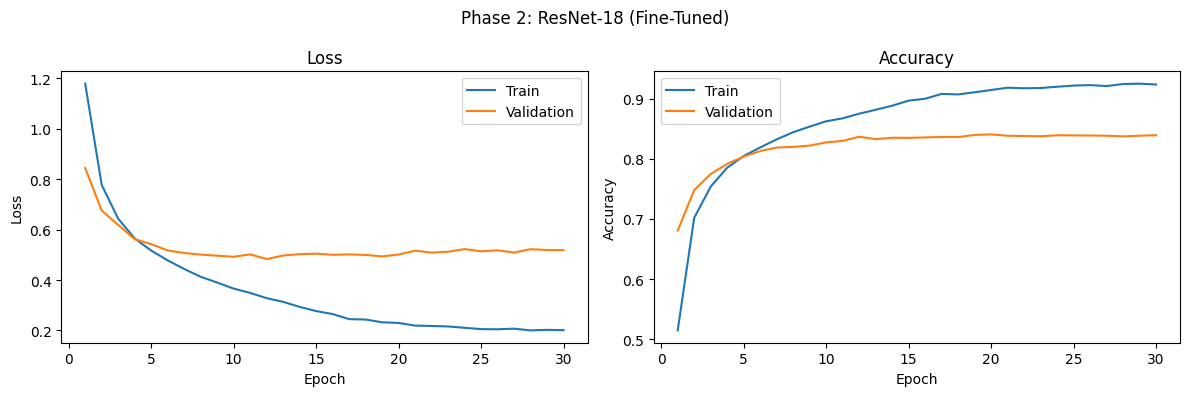

Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/resnet18/phase2_finetuned/training_history.png


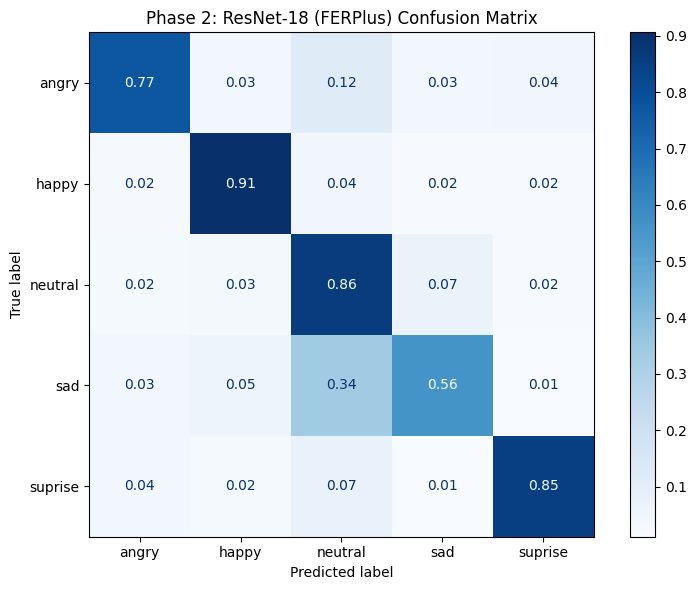

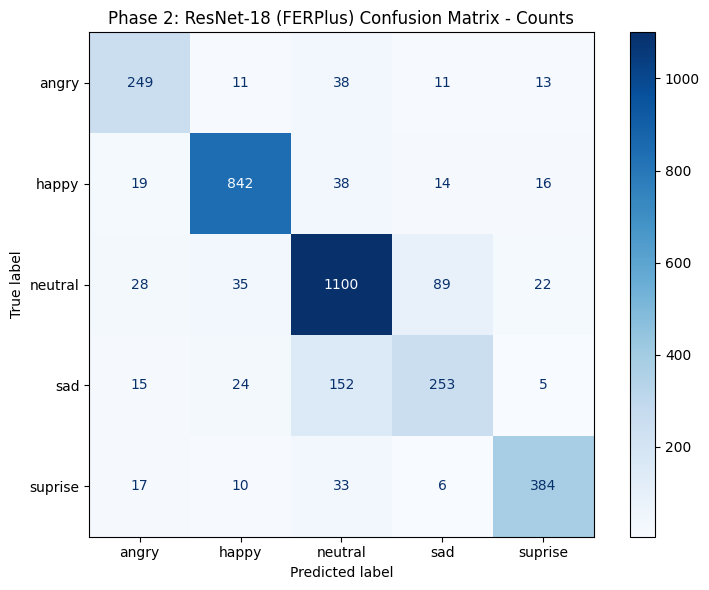

Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/resnet18/phase2_finetuned/confusion_matrix.png
Saved: /content/adaptive-emotion-aware-virtual-interaction-system/results/resnet18/phase2_finetuned/confusion_matrix_counts.png


In [20]:
if not run_phase2:
    print("Phase 2 skipped.")
else:
    plot_training_history(
        history_p2,
        "Phase 2: ResNet-18 (Fine-Tuned)",
        P2_DIR / "training_history.png",
    )

    plot_confusion_matrices(
        y_true_p2, y_pred_p2, CLASS_NAMES,
        "Phase 2: ResNet-18 (FERPlus)", P2_DIR,
    )

In [21]:
if not run_phase2:
    print("Phase 2 skipped.")
else:
    save_outputs(
        history=history_p2,
        y_true=y_true_p2,
        y_pred=y_pred_p2,
        class_names=CLASS_NAMES,
        model_name="resnet18_phase2_finetuned",
        best_val_acc=best_val_acc_p2,
        extra_info={
            "phase": "phase2_partial_finetune",
            "model_class": "models.resnet.ResNet18",
            "backbone_lr": PHASE2_BACKBONE_LR,
            "classifier_lr": PHASE2_CLASSIFIER_LR,
            "unfreeze_last_n": PHASE2_UNFREEZE_LAST_N,
            "classifier_head": "512 -> 256 -> 5",
            "trainable_params": sum(
                p.numel() for p in model_p2.parameters()
                if p.requires_grad
            ),
        },
        save_dir=P2_DIR,
    )

All outputs saved to: /content/adaptive-emotion-aware-virtual-interaction-system/results/resnet18/phase2_finetuned
--------------------------------------------------
  best_model.pth                            44256.5 KB
  confusion_matrix.png                         70.3 KB
  confusion_matrix_counts.png                  63.0 KB
  evaluation_summary.json                       1.7 KB
  training_history.json                         2.9 KB
  training_history.png                         69.0 KB


---

## 7. Final Comparison and Best Model Selection

In [22]:
# Select the best model across phases and save it as
# the canonical checkpoint.
print("=" * 70)
print("FINAL COMPARISON")
print("=" * 70)
print(
    f"  Phase 1 (frozen):     "
    f"val {best_val_acc_p1:.2%} | test {test_acc_p1:.2%}"
)

if run_phase2:
    print(
        f"  Phase 2 (fine-tuned): "
        f"val {best_val_acc_p2:.2%} | test {test_acc_p2:.2%}"
    )
    improvement = test_acc_p2 - test_acc_p1
    print(
        f"  Improvement:          "
        f"{improvement:+.2%} test accuracy"
    )
    print()

    if test_acc_p2 > test_acc_p1:
        best_source = P2_DIR / "best_model.pth"
        best_phase = "Phase 2 (fine-tuned)"
    else:
        best_source = P1_DIR / "best_model.pth"
        best_phase = "Phase 1 (frozen)"
else:
    best_source = P1_DIR / "best_model.pth"
    best_phase = "Phase 1 (frozen)"

# Copy the best checkpoint to the canonical location
canonical_path = OUTPUT_DIR / "best_resnet18.pth"
shutil.copy2(best_source, canonical_path)

print(f"Best model: {best_phase}")
print(f"Saved to:   {canonical_path}")

# Copy all outputs to Google Drive
copy_to_drive(OUTPUT_DIR, DRIVE_OUTPUT_DIR)

FINAL COMPARISON
  Phase 1 (frozen):     val 53.44% | test 53.21%
  Phase 2 (fine-tuned): val 84.07% | test 82.59%
  Improvement:          +29.38% test accuracy

Best model: Phase 2 (fine-tuned)
Saved to:   /content/adaptive-emotion-aware-virtual-interaction-system/results/resnet18/best_resnet18.pth
Copied outputs to Drive: /content/drive/MyDrive/emotion_project/results/resnet18


## Summary

**Outputs saved to `results/resnet18/`:**

| File | Description |
|------|-------------|
| `best_resnet18.pth` | Best model checkpoint (by test accuracy) |
| `phase1_frozen/` | Phase 1 outputs: checkpoint, history, plots |
| `phase2_finetuned/` | Phase 2 outputs: checkpoint, history, plots |

**Each phase directory contains:**

| File | Description |
|------|-------------|
| `best_model.pth` | Phase-specific best checkpoint |
| `training_history.json` | Per-epoch train/val loss and accuracy |
| `training_history.png` | Loss and accuracy curves |
| `evaluation_summary.json` | Test accuracy and per-class report |
| `confusion_matrix.png` | Normalized confusion matrix |
| `confusion_matrix_counts.png` | Raw count confusion matrix |